# ENTRENANDO MODELO DE ML PARA PREDECIR PICOS DE MALARIA EN PERÚ
## DATASET: Vigilancia Malaria 2009 - 2024 (Limpiado)
### NOMBRE: CALED ITAMAR LIMA ROQUE

# PASO 1: INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2: CARGAMOS EL DATASET

In [ ]:
# Cargamos el archivo limpio que generamos en el EDA
PATH_CLEAN_CSV = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/vigilancia_malaria_2009_2024_cleaned.csv'
df = pd.read_csv(PATH_CLEAN_CSV)
df

/tmp/ipykernel_10139/949653445.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH_CLEAN_CSV)


,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,TUMBES,ZARUMILLA,AGUAS VERDES,AGUAS VERDES,MALARIA POR P. VIVAX,2009,15,B51,24,240302,2403020001,32,A,M
1,ANCASH,CASMA,BUENA VISTA ALTA,HUANCHUY,MALARIA POR P. VIVAX,2009,18,B51,2,20802,208020002,7,A,M
2,MADRE DE DIOS,MANU,MADRE DE DIOS,BOCA PUKIRI,MALARIA POR P. VIVAX,2009,19,B51,17,170203,1702030010,17,A,M
3,PIURA,SULLANA,SULLANA,HUANGALA,MALARIA POR P. VIVAX,2009,21,B51,31,200601,2006010023,53,A,F
4,ANCASH,YUNGAY,RANRAHIRCA,CAJAPAMPA,MALARIA POR P. VIVAX,2009,22,B51,2,22006,220060006,24,A,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578519,LORETO,MARISCAL RAMON CASTILLA,PEBAS,COCHIQUINAS,MALARIA P. FALCIPARUM,2024,50,B50,16,160402,1604020058,73,A,M
578520,LORETO,MAYNAS,IQUITOS,IQUITOS,MALARIA POR P. VIVAX,2024,28,B51,16,160101,1601010001,64,A,F
578521,LORETO,LORETO,URARINAS,SANTA ROSA DE FIRMEZA,MALARIA POR P. VIVAX,2024,34,B51,16,160305,1603051011,32,A,M
578522,LORETO,LORETO,URARINAS,SANTA ROSA DE FIRMEZA,MALARIA P. FALCIPARUM,2024,48,B50,16,160305,1603051011,14,A,F


## PASO 3: PREPARACIÓN Y SELECCIÓN DE VARIABLES

In [ ]:
# Para predecir picos por semana, necesitamos agrupar los datos históricos.
# Contaremos la cantidad de casos por departamento, provincia, año y semana.
df_grouped = df.groupby(['departamento', 'provincia', 'ano', 'semana']).size().reset_index(name='total_casos')
df_grouped

,departamento,provincia,ano,semana,total_casos
0,AMAZONAS,BAGUA,2009,25,1
1,AMAZONAS,BAGUA,2009,26,2
2,AMAZONAS,BAGUA,2009,29,1
3,AMAZONAS,BAGUA,2009,34,1
4,AMAZONAS,BAGUA,2010,2,1
...,...,...,...,...,...
13579,UCAYALI,PADRE ABAD,2018,11,2
13580,UCAYALI,PADRE ABAD,2021,21,1
13581,UCAYALI,PURUS,2009,18,1
13582,UCAYALI,PURUS,2010,7,1


In [ ]:
df_grouped.columns

Index(['departamento', 'provincia', 'ano', 'semana', 'total_casos'], dtype='object')

In [ ]:
# Seleccionamos las variables finales a utilizar para nuestro modelo.
# No consideramos el "futuro", por lo que usaremos año, semana, departamento y provincia para predecir total_casos
df_model = df_grouped[['departamento', 'provincia', 'ano', 'semana', 'total_casos']]
df_model

,departamento,provincia,ano,semana,total_casos
0,AMAZONAS,BAGUA,2009,25,1
1,AMAZONAS,BAGUA,2009,26,2
2,AMAZONAS,BAGUA,2009,29,1
3,AMAZONAS,BAGUA,2009,34,1
4,AMAZONAS,BAGUA,2010,2,1
...,...,...,...,...,...
13579,UCAYALI,PADRE ABAD,2018,11,2
13580,UCAYALI,PADRE ABAD,2021,21,1
13581,UCAYALI,PURUS,2009,18,1
13582,UCAYALI,PURUS,2010,7,1


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [ ]:
categorical_columns = df_model.select_dtypes(object).columns
categorical_columns

Index(['departamento', 'provincia'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df_model[cc].value_counts())

**************************************************
departamento
LORETO           5792
SAN MARTIN       1478
JUNIN            1124
AYACUCHO          832
CUSCO             700
LA LIBERTAD       667
AMAZONAS          607
MADRE DE DIOS     580
UCAYALI           531
PIURA             361
TUMBES            360
CAJAMARCA         211
LAMBAYEQUE        144
PASCO             123
APURIMAC           23
HUANUCO            20
ANCASH             15
HUANCAVELICA       11
LIMA                3
ICA                 1
PUNO                1
Name: count, dtype: int64
**************************************************
provincia
MAYNAS                     835
REQUENA                    834
MARISCAL RAMON CASTILLA    833
LORETO                     832
DATEM DEL MARA�ON          830
                          ... 
HUAYTARA                     1
ACOBAMBA                     1
HUAMALIES                    1
SANDIA                       1
SECHURA                      1
Name: count, Length: 98, dtype: int64


In [ ]:
# En este caso, tanto departamento como provincia no tienen un orden jerárquico inherente,
# por lo que ambas irán a OneHotEncoder. No tenemos OrdinalCols estrictas.
ordinal_cols = []
onehot_cols = list(categorical_columns)
print(ordinal_cols, onehot_cols)

[] ['departamento', 'provincia']


## 4.4 CODIFICAMOS USANDO LOS MODULOS COMPOSE Y PREPROCESSING DE SKLEARN

In [ ]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(sparse_output=False, handle_unknown='ignore'), onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['departamento', 'provincia'])])

### 4.4.2 APLICAMOS EL TRANSFOMER AL DATASET

In [ ]:
data_transformed = transformer.fit_transform(df_model)

data_transformed_df = (
    pd.DataFrame(
        data_transformed,
        columns = transformer.get_feature_names_out(),
        index=df_model.index
    )
)
data_transformed_df

,onehotencoder__departamento_AMAZONAS,onehotencoder__departamento_ANCASH,onehotencoder__departamento_APURIMAC,onehotencoder__departamento_AYACUCHO,onehotencoder__departamento_CAJAMARCA,onehotencoder__departamento_CUSCO,onehotencoder__departamento_HUANCAVELICA,onehotencoder__departamento_HUANUCO,onehotencoder__departamento_ICA,onehotencoder__departamento_JUNIN,...,onehotencoder__provincia_UCAYALI,onehotencoder__provincia_URUBAMBA,onehotencoder__provincia_UTCUBAMBA,onehotencoder__provincia_VILCAS HUAMAN,onehotencoder__provincia_VIRU,onehotencoder__provincia_YUNGAY,onehotencoder__provincia_ZARUMILLA,remainder__ano,remainder__semana,remainder__total_casos
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,25.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,26.0,2.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,29.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,34.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2010.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2018.0,11.0,2.0
13580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021.0,21.0,1.0
13581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,18.0,1.0
13582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2010.0,7.0,1.0


In [ ]:
# Limpiamos los nombres de las columnas generadas por el transformer al estilo del docente
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,departamento_AMAZONAS,departamento_ANCASH,departamento_APURIMAC,departamento_AYACUCHO,departamento_CAJAMARCA,departamento_CUSCO,departamento_HUANCAVELICA,departamento_HUANUCO,departamento_ICA,departamento_JUNIN,...,provincia_UCAYALI,provincia_URUBAMBA,provincia_UTCUBAMBA,provincia_VILCAS HUAMAN,provincia_VIRU,provincia_YUNGAY,provincia_ZARUMILLA,ano,semana,total_casos
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,25.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,26.0,2.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,29.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,34.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2010.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2018.0,11.0,2.0
13580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021.0,21.0,1.0
13581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2009.0,18.0,1.0
13582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2010.0,7.0,1.0


In [ ]:
data_transformed_df.dtypes

,0
departamento_AMAZONAS,float64
departamento_ANCASH,float64
departamento_APURIMAC,float64
departamento_AYACUCHO,float64
departamento_CAJAMARCA,float64
...,...
provincia_YUNGAY,float64
provincia_ZARUMILLA,float64
ano,float64
semana,float64


# PASO 5 - CORRELACIONES

In [ ]:
corr_matrix = data_transformed_df.corr()
corr_target = corr_matrix['total_casos']
corr_target.sort_values(ascending=False).head(15) # Mostramos el top 15 por la gran cantidad de columnas generadas

,total_casos
total_casos,1.000000
provincia_MAYNAS,0.498645
departamento_LORETO,0.436092
provincia_DATEM DEL MARA�ON,0.298625
provincia_LORETO,0.245346
ano,0.080554
provincia_MARISCAL RAMON CASTILLA,0.079690
semana,0.005483
provincia_CA�ETE,-0.003993
provincia_JAUJA,-0.004092


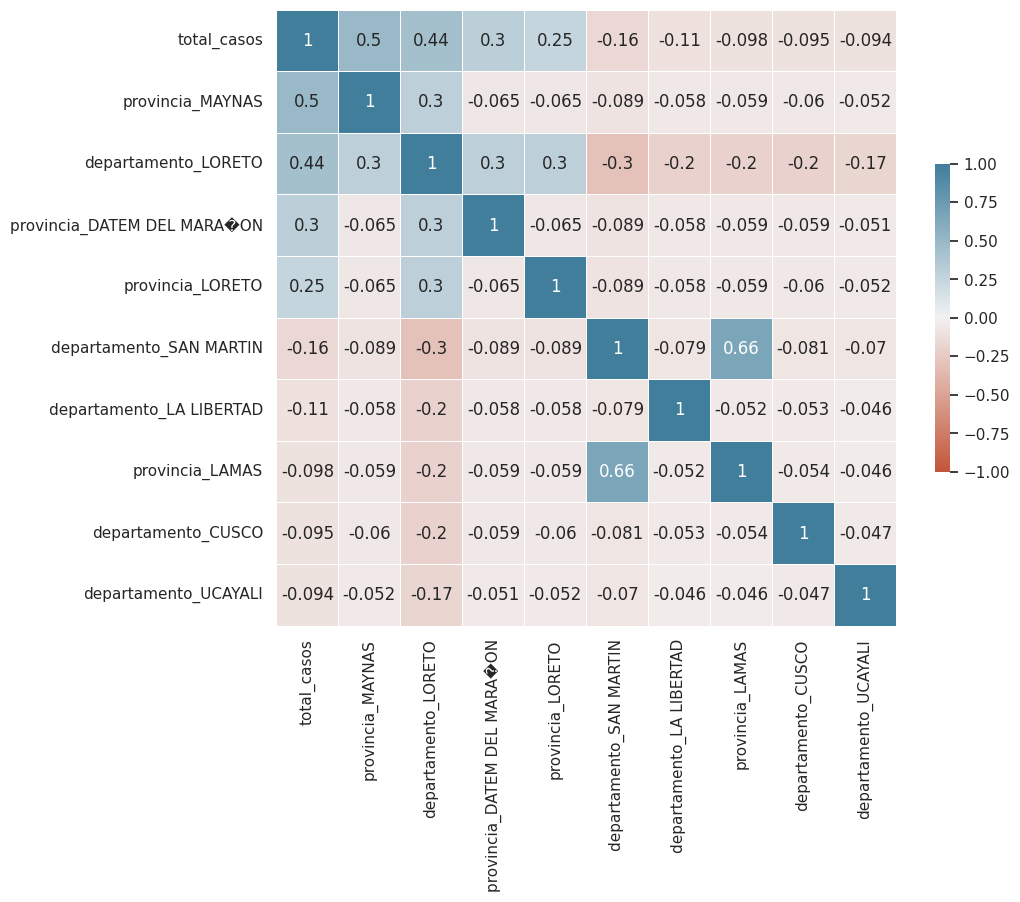

In [ ]:
# Por la alta dimensionalidad tras el OneHotEncoding, graficamos solo las variables más correlacionadas
top_corr_features = corr_target.abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=data_transformed_df[top_corr_features].corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)
plt.show()

# PASO 6 - SEPARACIÓN DE DATOS (TRAIN Y TEST)

In [ ]:
from sklearn.model_selection import train_test_split

# Separamos nuestra variable objetivo (y) de nuestras características (X)
X = data_transformed_df.drop('total_casos', axis=1)
y = data_transformed_df['total_casos']

# Split 80/20 como es estándar en ML básico
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (10867, 121)
Tamaño de prueba: (2717, 121)


# PASO 7 - ENTRENAMIENTO DEL MODELO Y MÉTRICAS
## Utilizaremos un modelo de Random Forest Regressor, ideal para capturar no linealidades y estacionalidad sin requerir escalado avanzado

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instanciamos y entrenamos el modelo
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Realizamos las predicciones con el set de prueba
y_pred = modelo_rf.predict(X_test)

In [ ]:
# Evaluamos el modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MÉTRICAS DEL MODELO:")
print("*"*30)
print(f"MAE (Error Absoluto Medio): {mae:.2f} casos")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} casos")
print(f"R2 Score: {r2:.4f}")

MÉTRICAS DEL MODELO:
******************************
MAE (Error Absoluto Medio): 10.10 casos
RMSE (Raíz del Error Cuadrático Medio): 22.32 casos
R2 Score: 0.9292


# PASO 8 - EXPORTACIÓN DEL MODELO PARA FLASK

In [ ]:
import joblib

# Exportamos el modelo
PATH_MODELO = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/modelo_malaria_rf.pkl'
joblib.dump(modelo_rf, PATH_MODELO)

# También exportamos el transformer para aplicarlo a nuevos datos ingresados en la web
PATH_TRANSFORMER = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/transformer_malaria.pkl'
joblib.dump(transformer, PATH_TRANSFORMER)

print(f"Modelo exportado en: {PATH_MODELO}")
print(f"Transformer exportado en: {PATH_TRANSFORMER}")

Modelo exportado en: /content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/modelo_malaria_rf.pkl
Transformer exportado en: /content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/transformer_malaria.pkl
